In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pytest

from QAssemble.Crystal import Crystal
from QAssemble.FLatDyn import G0
# from QAssemble.FLocDyn import FLocDyn
from QAssemble.BLatDyn import P
from QAssemble.utility.Causal import CausalProjector
from QAssemble.utility.DLR import DLR


In [2]:
def _single_band_hubbard():
    crystal = Crystal(
        {
            "RVec": [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
            "Basis": [[[0, 0, 0], 1]],
            "NSpin": 1,
            "NElec": 1.0,
            "KGrid": [2, 2, 2],
        }
    )
    kx, ky, kz = crystal.kpoint[:, 0], crystal.kpoint[:, 1], crystal.kpoint[:, 2]
    eps = -2.0 * (
        np.cos(2.0 * np.pi * kx)
        + np.cos(2.0 * np.pi * ky)
        + np.cos(2.0 * np.pi * kz)
    )
    hamtb = np.zeros((1, 1, 1, crystal.nk), dtype=np.complex128, order="F")
    hamtb[0, 0, 0, :] = eps
    dlr = DLR({"beta": 20.0, "cutoff": 50.0, "eps": 1.0e-12})
    return crystal, dlr, hamtb

In [3]:
# test_flocdyn_causal_projection_single_band_hubbard_average()

In [4]:
crystal, dlr, hamtb = _single_band_hubbard()

g0 = G0(crystal=crystal, dlr=dlr, hamtb=hamtb, hdf5file=None)

In [5]:
g0_kf = np.zeros((1, 1, 1, crystal.nk, len(dlr.MatsubaraFermionUniformFull())), dtype=np.complex128, order="F")

# for i in range(crystal.nk):
#     g0_kf[0, 0, 0, i, :] = dlr.MatsubaraDLR2Uniform(g0.kf[0, 0, 0, i, :]).reshape(len(dlr.MatsubaraFermionUniform()))

In [6]:
for i in range(crystal.nk):
    fxx = dlr.dF.dlr_from_matsubara(g0.kf[0, 0, 0, i, :], beta=dlr.beta)
    z = dlr.MatsubaraFermionUniformFull() * 1j
    g0_kf[0, 0, 0, i, :] = dlr.dF.eval_dlr_freq(fxx[:, None, None], z, beta=dlr.beta, xi=-1)[:, 0, 0]

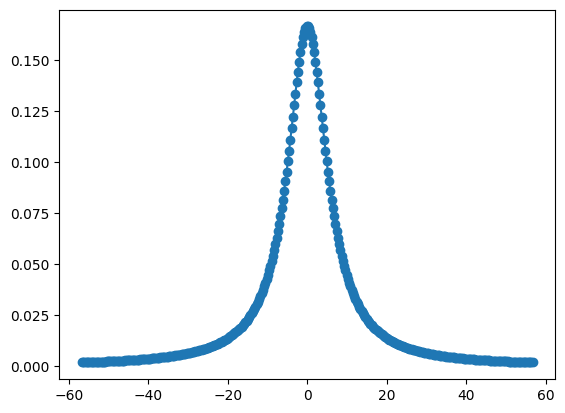

In [7]:
plt.plot(dlr.MatsubaraFermionUniformFull(), g0_kf[0, 0, 0, 0, :].real, "o-", label="real part")
plt.show()

In [8]:
tempmat = g0_kf.copy(order="F")

high_list = []
for i in range(len(z)):
    if (abs(z[i].imag) < dlr.cutoff * 2/3):
        high_list.append(i)
print(high_list)

[75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279,

In [9]:
len(z)
print(len(z), len(high_list))

362 212


In [10]:
norm = 1e-2
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

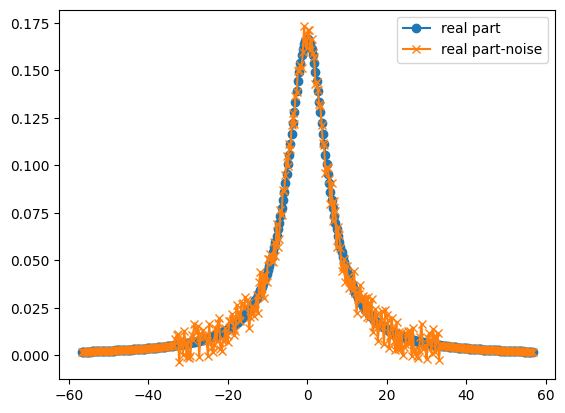

In [11]:
plt.plot(dlr.MatsubaraFermionUniformFull(), g0_kf[0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(dlr.MatsubaraFermionUniformFull(), tempmat[0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

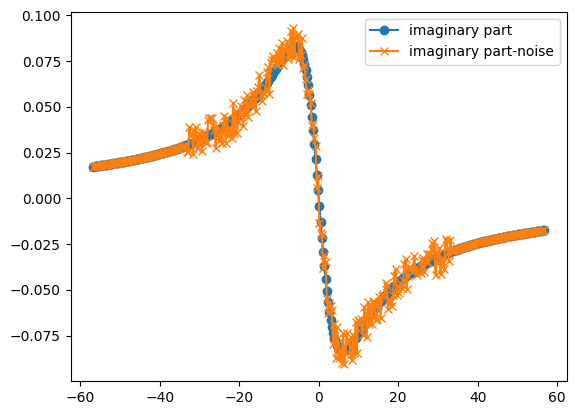

In [12]:
plt.plot(dlr.MatsubaraFermionUniformFull(), g0_kf[0, 0, 0, 0, :].imag, "o-", label="imaginary part")
plt.plot(dlr.MatsubaraFermionUniformFull(), tempmat[0, 0, 0, 0, :].imag, "x-", label="imaginary part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

In [13]:
# input data carries high-frequency noise, so the causal moment/sign
# constraints cannot be met to the 1e-8 default. constraint_tol="auto" sets
# the per-channel acceptance tolerance to the data noise floor automatically
# (auto_safety * node_residual). Output is returned on the DLR grid.
proj = g0.CausalProjection(tempmat, grid="uniform", constraint_tol="auto")
proj.shape

(1, 1, 1, 8, 39)

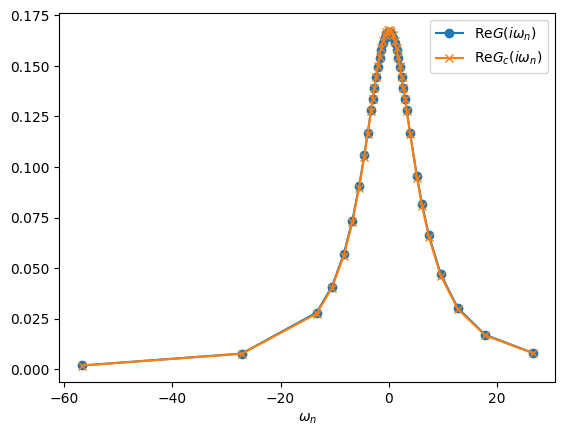

In [14]:
plt.plot(dlr.omega, g0.kf[0, 0, 0, 0, :].real, "o-", label=r"Re$G(i\omega_n)$")
plt.plot(dlr.omega, proj[0, 0, 0, 0, :].real, "x-", label=r"Re$G_{c}(i\omega_n)$")
plt.xlabel(r"$\omega_n$")

plt.legend()
plt.show()

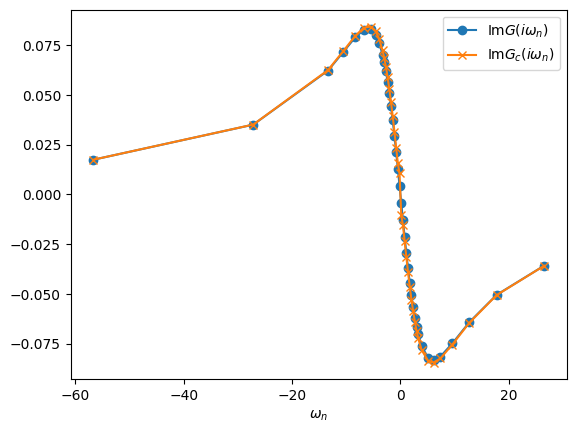

In [15]:
plt.plot(dlr.omega, g0.kf[0, 0, 0, 0, :].imag, "o-", label=r"Im$G(i\omega_n)$")
plt.plot(dlr.omega, proj[0, 0, 0, 0, :].imag, "x-", label=r"Im$G_{c}(i\omega_n)$")
plt.xlabel(r"$\omega_n$")

plt.legend()
plt.show()

In [16]:
p = P(crystal=crystal, dlr = dlr, green=g0.rt, hdf5file=None)

In [17]:
dlr.MatsubaraBosonUniform()

array([-105.87167243, -105.55751316, -105.2433539 , -104.92919463,
       -104.61503536, -104.3008761 , -103.98671683, -103.67255757,
       -103.3583983 , -103.04423904, -102.73007977, -102.41592051,
       -102.10176124, -101.78760198, -101.47344271, -101.15928345,
       -100.84512418, -100.53096491, -100.21680565,  -99.90264638,
        -99.58848712,  -99.27432785,  -98.96016859,  -98.64600932,
        -98.33185006,  -98.01769079,  -97.70353153,  -97.38937226,
        -97.075213  ,  -96.76105373,  -96.44689447,  -96.1327352 ,
        -95.81857593,  -95.50441667,  -95.1902574 ,  -94.87609814,
        -94.56193887,  -94.24777961,  -93.93362034,  -93.61946108,
        -93.30530181,  -92.99114255,  -92.67698328,  -92.36282402,
        -92.04866475,  -91.73450548,  -91.42034622,  -91.10618695,
        -90.79202769,  -90.47786842,  -90.16370916,  -89.84954989,
        -89.53539063,  -89.22123136,  -88.9070721 ,  -88.59291283,
        -88.27875357,  -87.9645943 ,  -87.65043504,  -87.33627

In [18]:
p_kf = np.zeros((1, 1, 1, 1, crystal.nk, len(dlr.MatsubaraBosonUniform())), dtype=np.complex128, order="F")


In [19]:
p.kf.shape

(1, 1, 1, 1, 8, 47)

In [20]:
from scipy.linalg import lu_solve

p_kf = np.zeros((1, 1, 1, 1, crystal.nk, len(dlr.MatsubaraBosonUniform())),
                dtype=np.complex128, order="F")

for i in range(crystal.nk):
    gq = p.kf[0, 0, 0, 0, i, :]

    fxx = lu_solve((dlr.dB.dlrmf2cf, dlr.dB.mf2cfpiv), gq[:, None] / dlr.beta)
    fxx /= dlr.dB.bosonic_corr_x[:, None]

    z = dlr.MatsubaraBosonUniform() * 1j
    p_kf[0, 0, 0, 0, i, :] = dlr.dB.eval_dlr_freq(
        fxx, z, beta=dlr.beta, xi=1
    )[:, 0]

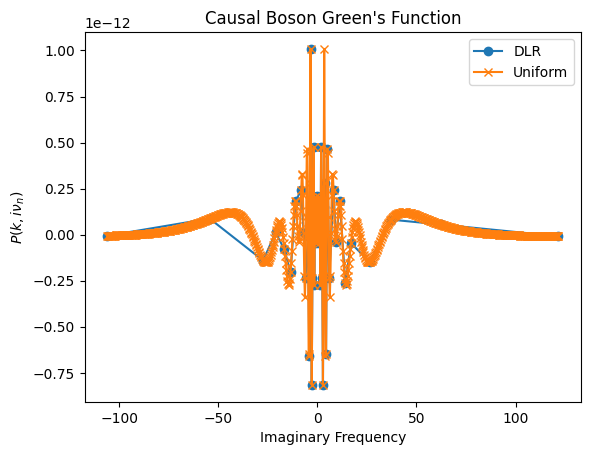

In [21]:
plt.plot(dlr.nu, p.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].real, "x-", label="Uniform")
plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$P(k, i\nu_n)$")
plt.title("Causal Boson Green's Function")
plt.legend()
plt.show()

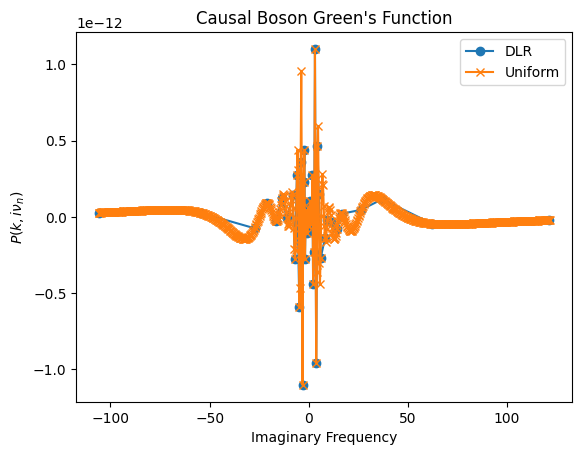

In [22]:
plt.plot(dlr.nu, p.kf[0, 0, 0, 0, 0, :].imag, "o-", label="DLR")
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].imag, "x-", label="Uniform")
plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$P(k, i\nu_n)$")
plt.title("Causal Boson Green's Function")
plt.legend()
plt.show()

In [23]:
tempmat = p_kf.copy(order="F")

high_list = []
for i in range(len(z)):
    if (abs(z[i].imag) < dlr.cutoff * 2/3):
        high_list.append(i)
print(high_list)

[231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430,

In [24]:
norm = 1e-4
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

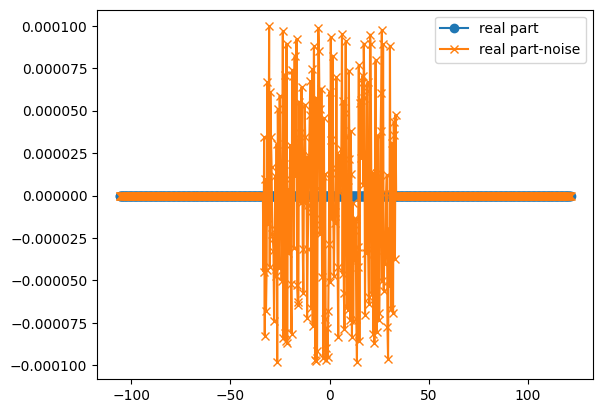

In [25]:
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

In [26]:
proj = p.CausalProjection(tempmat, grid="uniform", constraint_tol="auto")

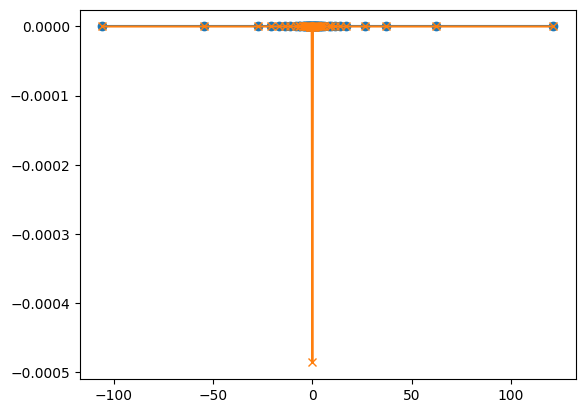

In [27]:
plt.plot(dlr.nu, p.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(dlr.nu, proj[0, 0, 0, 0, 0, :].real, "x-", label="Causal")

clean rel err  interp: 0.0
clean rel err  lstsq : 1.6364903540892376e-15


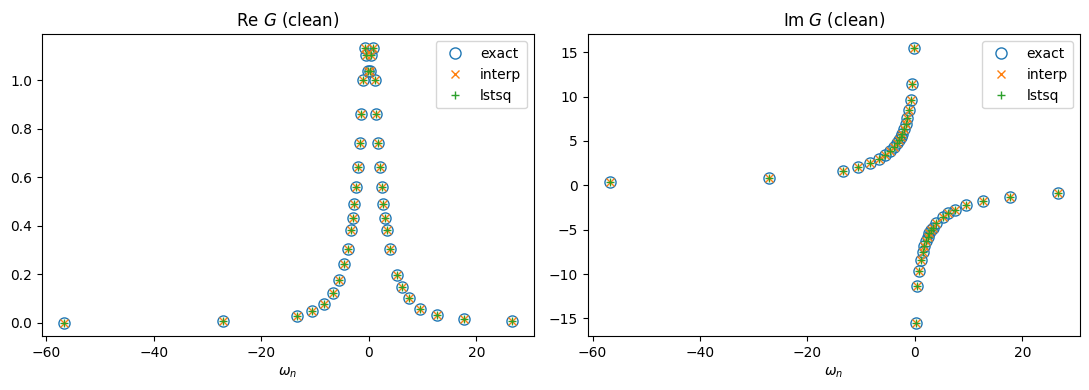

noisy rel err  interp: 0.0003456118300561294
noisy rel err  lstsq : 0.00026815986379223264


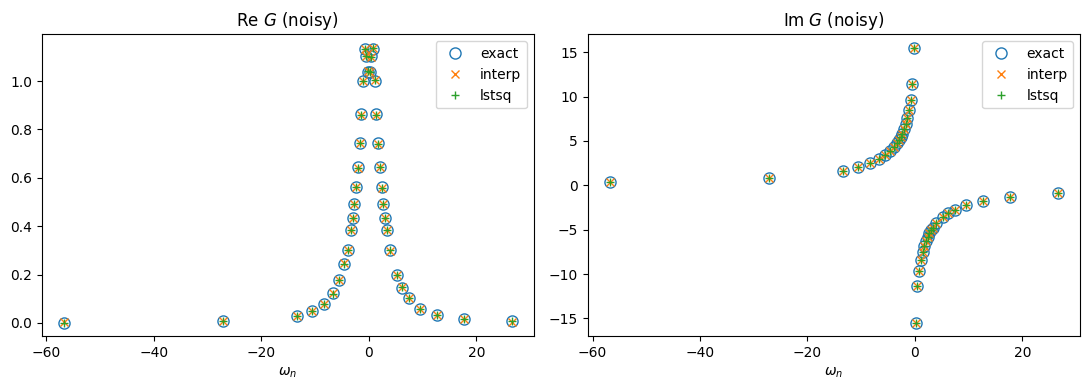

In [29]:
# --- exact vs lstsq vs interp: uniform -> DLR conversion ---
# MatsubaraUniform2DLR was switched from a pydlr global least-squares fit to a
# direct per-node linear interpolation.  Compare both against the exact DLR-grid
# values for a clean and a noisy fermionic channel.  On clean data the DLR nodes
# are a subset of the uniform grid, so interpolation is exact; lstsq is also
# near-exact.  Noise shows the qualitative difference (global fit vs local).
import numpy as np
import matplotlib.pyplot as plt

crystal, dlr, _ = _single_band_hubbard()

# a clean causal channel built from decaying DLR coefficients
rank = len(dlr.omega)
rng = np.random.default_rng(0)
coeff = -np.abs(rng.standard_normal((rank, 1, 1)))
omega_u = dlr.MatsubaraFermionUniformFull()
exact = dlr.dF.eval_dlr_freq(coeff, 1j * dlr.omega, dlr.beta, xi=-1)[:, 0, 0]
uniform = dlr.dF.eval_dlr_freq(coeff, 1j * omega_u, dlr.beta, xi=-1)[:, 0, 0]

# current (interp) conversion
interp_back = dlr.MatsubaraUniform2DLR(uniform, sign=-1)

# reference lstsq conversion, recomputed inline so the cell is self-contained
fxx = dlr.dF.lstsq_dlr_from_matsubara(w_q=omega_u * 1j,
                                      G_qaa=uniform[:, None, None],
                                      beta=dlr.beta)
lstsq_back = dlr.dF.matsubara_from_dlr(G_xaa=fxx, beta=dlr.beta, xi=-1)[:, 0, 0]

print("clean rel err  interp:", np.linalg.norm(interp_back - exact) / np.linalg.norm(exact))
print("clean rel err  lstsq :", np.linalg.norm(lstsq_back - exact) / np.linalg.norm(exact))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, part, lbl in ((ax[0], np.real, "Re"), (ax[1], np.imag, "Im")):
    a.plot(dlr.omega, part(exact), "o", ms=8, mfc="none", label="exact")
    a.plot(dlr.omega, part(interp_back), "x", label="interp")
    a.plot(dlr.omega, part(lstsq_back), "+", label="lstsq")
    a.set_xlabel(r"$\omega_n$"); a.set_title(f"{lbl} $G$ (clean)"); a.legend()
fig.tight_layout(); plt.show()

# noisy channel: add high-frequency noise to the uniform data
noise = 1e-4 * np.max(np.abs(uniform))
r = np.random.default_rng(1)
noisy = uniform + noise * (r.standard_normal(uniform.shape) + 1j * r.standard_normal(uniform.shape))
interp_n = dlr.MatsubaraUniform2DLR(noisy, sign=-1)
fxx_n = dlr.dF.lstsq_dlr_from_matsubara(w_q=omega_u * 1j, G_qaa=noisy[:, None, None], beta=dlr.beta)
lstsq_n = dlr.dF.matsubara_from_dlr(G_xaa=fxx_n, beta=dlr.beta, xi=-1)[:, 0, 0]
print("noisy rel err  interp:", np.linalg.norm(interp_n - exact) / np.linalg.norm(exact))
print("noisy rel err  lstsq :", np.linalg.norm(lstsq_n - exact) / np.linalg.norm(exact))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, part, lbl in ((ax[0], np.real, "Re"), (ax[1], np.imag, "Im")):
    a.plot(dlr.omega, part(exact), "o", ms=8, mfc="none", label="exact")
    a.plot(dlr.omega, part(interp_n), "x", label="interp")
    a.plot(dlr.omega, part(lstsq_n), "+", label="lstsq")
    a.set_xlabel(r"$\omega_n$"); a.set_title(f"{lbl} $G$ (noisy)"); a.legend()
fig.tight_layout(); plt.show()


In [ ]:
# --- exact vs raw-uniform lstsq vs new interp->LU: uniform -> DLR conversion ---
# MatsubaraUniform2DLR now runs a 3-step pipeline: (1) linearly interpolate the
# uniform data onto the DLR Matsubara grid, (2) solve DLR coefficients exactly
# (square LU, dlr_from_matsubara), (3) re-evaluate (matsubara_from_dlr).  This
# replaces fitting DLR coefficients DIRECTLY from the raw uniform grid in one
# global lstsq shot, which is ill-conditioned.  Compare both against the exact
# DLR-grid values for a clean and a noisy fermionic channel.
import numpy as np
import matplotlib.pyplot as plt

crystal, dlr, _ = _single_band_hubbard()

rank = len(dlr.omega)
rng = np.random.default_rng(0)
coeff = -np.abs(rng.standard_normal((rank, 1, 1)))
omega_u = dlr.MatsubaraFermionUniformFull()
exact = dlr.dF.eval_dlr_freq(coeff, 1j * dlr.omega, dlr.beta, xi=-1)[:, 0, 0]
uniform = dlr.dF.eval_dlr_freq(coeff, 1j * omega_u, dlr.beta, xi=-1)[:, 0, 0]


def raw_uniform_lstsq(data):
    """Original path: fit DLR coeffs directly from the raw uniform grid (lstsq)."""
    fxx = dlr.dF.lstsq_dlr_from_matsubara(
        w_q=omega_u * 1j, G_qaa=np.asarray(data)[:, None, None], beta=dlr.beta
    )
    return dlr.dF.matsubara_from_dlr(G_xaa=fxx, beta=dlr.beta, xi=-1)[:, 0, 0]


# conditioning: the raw-lstsq kernel is near-singular, the LU system is not
cond_lu = np.linalg.cond(dlr.dF.dlrmf2cf)
k_qx = -1.0 / (omega_u[:, None] * 1j - dlr.dF.dlrrf[None, :] / dlr.beta)
cond_lstsq = np.linalg.cond(k_qx)
print(f"cond(LU square system) = {cond_lu:.3e}")
print(f"cond(raw-lstsq kernel)  = {cond_lstsq:.3e}   (ratio {cond_lstsq/cond_lu:.2e})")

lu_clean = dlr.MatsubaraUniform2DLR(uniform, sign=-1)          # new interp->LU path
raw_clean = raw_uniform_lstsq(uniform)                         # original raw lstsq
print("clean rel err  interp->LU:", np.linalg.norm(lu_clean - exact) / np.linalg.norm(exact))
print("clean rel err  raw lstsq :", np.linalg.norm(raw_clean - exact) / np.linalg.norm(exact))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, part, lbl in ((ax[0], np.real, "Re"), (ax[1], np.imag, "Im")):
    a.plot(dlr.omega, part(exact), "o", ms=8, mfc="none", label="exact")
    a.plot(dlr.omega, part(lu_clean), "x", label="interp->LU")
    a.plot(dlr.omega, part(raw_clean), "+", label="raw lstsq")
    a.set_xlabel(r"$\omega_n$"); a.set_title(f"{lbl} $G$ (clean)"); a.legend()
fig.tight_layout(); plt.show()

# noisy channel
noise = 0.02 * np.max(np.abs(uniform))
r = np.random.default_rng(1)
noisy = uniform + noise * (r.standard_normal(uniform.shape) + 1j * r.standard_normal(uniform.shape))
lu_n = dlr.MatsubaraUniform2DLR(noisy, sign=-1)
raw_n = raw_uniform_lstsq(noisy)
print("noisy rel err  interp->LU:", np.linalg.norm(lu_n - exact) / np.linalg.norm(exact))
print("noisy rel err  raw lstsq :", np.linalg.norm(raw_n - exact) / np.linalg.norm(exact))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, part, lbl in ((ax[0], np.real, "Re"), (ax[1], np.imag, "Im")):
    a.plot(dlr.omega, part(exact), "o", ms=8, mfc="none", label="exact")
    a.plot(dlr.omega, part(lu_n), "x", label="interp->LU")
    a.plot(dlr.omega, part(raw_n), "+", label="raw lstsq")
    a.set_xlabel(r"$\omega_n$"); a.set_title(f"{lbl} $G$ (noisy)"); a.legend()
fig.tight_layout(); plt.show()
